In [2]:
import pandas as pd
import numpy as np
import matplotlib
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path

scenario_parent_folder = Path(os.path.abspath('')) / 'logs' /  'unified' / 'buoy'

Ran with 
```
# Independent variables
independent_vars = {
    "nodeXCount" : list(np.arange(1, 26, 1)),
    "nodeYCount" : list(np.arange(1, 26, 1)),
    "nodeZCount": [1],
    "nodeZSpacing": [1],
    "nodeZOffset": list(np.arange(0, -1.8, -0.1)),
    "auvSpeed": [0],
    "propagationModel": ["underwater"],
    "waterTemperature": [20],
    "waterSalinity": [0.01],
    "stopTime": [10*60],  # seconds
    "channelWidth": [1],
    "packetStatsConfig": ["means"],
    "enablePositionLogging": ["true"],
    "powerLoggingConfig": ["short"],
    "enableMacStats": ["true"],
    "scenarioFolderPath": ["\"unified/buoy/run\""]
}

# Dependent variables defined via lambda functions. 
# Each lambda receives a dict with the current independent variables.
dependent_vars = {
    # 1.8 because otherwise we'll have nodes out of range
    "nodeXSpacing": lambda args: 1.8 / (args["nodeXCount"] - 1) if args["nodeXCount"] > 1 else 1,
    "nodeXOffset": lambda args: -args["nodeXSpacing"] * (args["nodeXCount"] - 1) / 2,
    "nodeYSpacing": lambda args: 1.8 / (args["nodeYCount"] - 1) if args["nodeYCount"] > 1 else 1,
    "nodeYOffset": lambda args: -args["nodeYSpacing"] * (args["nodeYCount"] - 1) / 2,
    "dataRatePHY": lambda args: "OfdmRate1_2MbpsBW1MHz" if args["channelWidth"] == 1 else "OfdmRate7_8MbpsBW2MHz",
}
```

In [3]:
def read_sim_config_file(scenario_folder:Path) -> dict:
    sim_config = {}
    with open(scenario_folder / 'SimConfig.txt') as f:
        for line in f:
            if line.startswith('--'):
                key, value = line.strip().split('=')
                key = key[2:]  # Remove the leading '--'
                
                # Try to convert value to appropriate data type
                try:
                    # First try as int
                    sim_config[key] = int(value)
                except ValueError:
                    try:
                        # Then try as float
                        sim_config[key] = float(value)
                    except ValueError:
                        # Keep as string if not numeric
                        sim_config[key] = value
    return sim_config

In [4]:
# Get all the scenario folders
scenario_folders = sorted([x for x in scenario_parent_folder.iterdir() if x.is_dir()])
print(f"Will load {len(scenario_folders)} scenario runs")

packet_logging_stats_summary_dfs = []
power_state_stats = pd.DataFrame()
for i, scenario_folder in enumerate(scenario_folders):
    sim_config = read_sim_config_file(scenario_folder)
    print(f"[{i+1}/{len(scenario_folders)}] Loading scenario {scenario_folder.name}")

    # Load the packet logging stats
    if (scenario_folder / 'PacketLoggingStatsSummary.csv').exists():
        packet_logging_stats_summary_df = pd.read_csv(scenario_folder / 'PacketLoggingStatsSummary.csv', delimiter=';', index_col=False)
        for key, value in sim_config.items():
            packet_logging_stats_summary_df[key] = value
        packet_logging_stats_summary_dfs.append(packet_logging_stats_summary_df)
    else:
        print(f"PacketLoggingStatsSummary.csv not found in {scenario_folder.name}")
        
    # Load the power state stats
    if (scenario_folder / 'PowerStateStats.csv').exists():
        ps_temp_df = pd.read_csv(scenario_folder / 'PowerStateStats.csv', delimiter=';', index_col=False)
        for col in ['SLEEPTime', 'IDLETime', 'TXTime', 'RXTime', "CCA_BUSYTime", "SWITCHINGTime"]:
            ps_temp_df[col] = ps_temp_df[col].str.replace('ns', '').astype(float)
            # Ignore the APs as we assume they are always on
            power_state_stats.loc[i, col] = ps_temp_df[ps_temp_df['NodeType'] == "STA"][col].mean()
        for key, value in sim_config.items():
            power_state_stats.loc[i, key] = value
    else:
        print(f"PowerStateStats.csv not found in {scenario_folder.name}")
        
packet_logging_stats_summary = pd.concat(packet_logging_stats_summary_dfs)
for col in ['MeanLatencySTAToAP', 'MeanLatencyAPToSTA']:
    packet_logging_stats_summary[col] = abs(packet_logging_stats_summary[col].str.replace('ns', '').astype(float))

Will load 1357 scenario runs
[1/1357] Loading scenario run_1743188919537336406
[2/1357] Loading scenario run_1743188919537336518
[3/1357] Loading scenario run_1743188919537336579
[4/1357] Loading scenario run_1743188919537336590
[5/1357] Loading scenario run_1743188919537336592
[6/1357] Loading scenario run_1743188919537344585
[7/1357] Loading scenario run_1743188919537348123
[8/1357] Loading scenario run_1743188919537362694
[9/1357] Loading scenario run_1743188919537378157
[10/1357] Loading scenario run_1743188919537379795
[11/1357] Loading scenario run_1743188919537419372
[12/1357] Loading scenario run_1743188919537458316
[13/1357] Loading scenario run_1743188919537479504
[14/1357] Loading scenario run_1743188919537533126
[15/1357] Loading scenario run_1743188919538705927
[16/1357] Loading scenario run_1743188919539452309
[17/1357] Loading scenario run_1743188919539503329
[18/1357] Loading scenario run_1743188919541558772
[19/1357] Loading scenario run_1743188939920627510
[20/1357] L

In [5]:
packet_logging_stats_summary

,CountPacketsSentSTAToAP,CountPacketsSentAPToSTA,MeanPacketSizeSTAToAP,MeanPacketSizeAPToSTA,MeanTxBeginCountSTAToAP,MeanTxBeginCountAPToSTA,MeanRxEndCountSTAToAP,MeanRxEndCountAPToSTA,MeanRxDropCountSTAToAP,MeanRxDropCountAPToSTA,...,packetStatsConfig,enablePositionLogging,powerLoggingConfig,enableMacStats,scenarioFolderPath,nodeXSpacing,nodeXOffset,nodeYSpacing,nodeYOffset,dataRatePHY
0,15277,17707,625.896,89.9995,2,1,2,1,0,0,...,means,true,short,true,unified/buoy/run,1.000000,0.0,1.000,0.0,OfdmRate1_2MbpsBW1MHz
0,15410,17729,625.897,89.9995,2,1,2,1,0,0,...,means,true,short,true,unified/buoy/run,1.000000,0.0,1.000,0.0,OfdmRate1_2MbpsBW1MHz
0,15438,17753,625.897,89.9995,2,1,2,1,0,0,...,means,true,short,true,unified/buoy/run,1.000000,0.0,1.000,0.0,OfdmRate1_2MbpsBW1MHz
0,15520,17853,625.830,89.9985,2,1,2,1,0,0,...,means,true,short,true,unified/buoy/run,1.000000,0.0,1.000,0.0,OfdmRate1_2MbpsBW1MHz
0,15457,17813,625.897,89.9996,2,1,2,1,0,0,...,means,true,short,true,unified/buoy/run,1.000000,0.0,1.000,0.0,OfdmRate1_2MbpsBW1MHz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,3052,3176,524.464,89.6716,2,1,1,1,0,0,...,means,true,short,true,unified/buoy/run,0.163636,-0.9,0.225,-0.9,OfdmRate1_2MbpsBW1MHz
0,225,352,101.680,87.0682,2,1,1,1,1,0,...,means,true,short,true,unified/buoy/run,0.163636,-0.9,0.225,-0.9,OfdmRate1_2MbpsBW1MHz
0,914,360,102.000,87.3000,1,1,1,1,0,0,...,means,true,short,true,unified/buoy/run,0.163636,-0.9,0.225,-0.9,OfdmRate1_2MbpsBW1MHz
0,267,54,102.000,92.6667,2,3,1,1,1,2,...,means,true,short,true,unified/buoy/run,0.163636,-0.9,0.225,-0.9,OfdmRate1_2MbpsBW1MHz


In [6]:
power_state_stats

,SLEEPTime,IDLETime,TXTime,RXTime,CCA_BUSYTime,SWITCHINGTime,nodeXCount,nodeYCount,nodeZCount,nodeZSpacing,...,packetStatsConfig,enablePositionLogging,powerLoggingConfig,enableMacStats,scenarioFolderPath,nodeXSpacing,nodeXOffset,nodeYSpacing,nodeYOffset,dataRatePHY
0,1.561360e+11,1.948882e+11,1.689495e+11,8.002992e+10,0.000000e+00,0.0,1.0,1.0,1.0,1.0,...,means,true,short,true,unified/buoy/run,1.000000,0.0,1.000,0.0,OfdmRate1_2MbpsBW1MHz
1,1.559338e+11,1.934039e+11,1.704148e+11,8.025072e+10,0.000000e+00,0.0,1.0,1.0,1.0,1.0,...,means,true,short,true,unified/buoy/run,1.000000,0.0,1.000,0.0,OfdmRate1_2MbpsBW1MHz
2,1.540676e+11,1.947761e+11,1.706620e+11,8.049792e+10,0.000000e+00,0.0,1.0,1.0,1.0,1.0,...,means,true,short,true,unified/buoy/run,1.000000,0.0,1.000,0.0,OfdmRate1_2MbpsBW1MHz
3,1.540925e+11,1.936171e+11,1.714610e+11,8.083292e+10,0.000000e+00,0.0,1.0,1.0,1.0,1.0,...,means,true,short,true,unified/buoy/run,1.000000,0.0,1.000,0.0,OfdmRate1_2MbpsBW1MHz
4,1.554894e+11,1.933434e+11,1.708157e+11,8.035536e+10,0.000000e+00,0.0,1.0,1.0,1.0,1.0,...,means,true,short,true,unified/buoy/run,1.000000,0.0,1.000,0.0,OfdmRate1_2MbpsBW1MHz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1334,4.204668e+10,1.299297e+11,1.567425e+10,4.075383e+11,4.809957e+09,0.0,12.0,9.0,1.0,1.0,...,means,true,short,true,unified/buoy/run,0.163636,-0.9,0.225,-0.9,OfdmRate1_2MbpsBW1MHz
1335,4.887100e+10,1.758899e+11,1.524944e+10,3.567072e+11,3.234828e+09,0.0,12.0,9.0,1.0,1.0,...,means,true,short,true,unified/buoy/run,0.163636,-0.9,0.225,-0.9,OfdmRate1_2MbpsBW1MHz
1336,4.104440e+10,1.583736e+11,1.718525e+10,3.796797e+11,3.669382e+09,0.0,12.0,9.0,1.0,1.0,...,means,true,short,true,unified/buoy/run,0.163636,-0.9,0.225,-0.9,OfdmRate1_2MbpsBW1MHz
1337,9.575858e+07,5.609212e+10,2.567990e+10,5.135150e+11,4.614563e+09,0.0,12.0,9.0,1.0,1.0,...,means,true,short,true,unified/buoy/run,0.163636,-0.9,0.225,-0.9,OfdmRate1_2MbpsBW1MHz


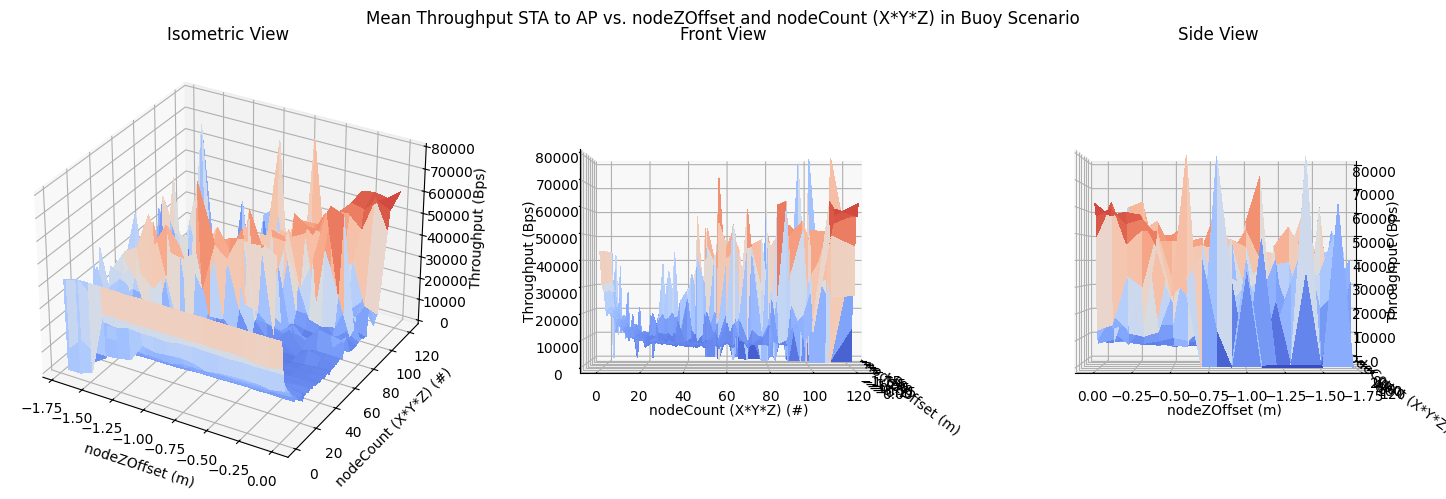

In [7]:
fig = plt.figure(figsize=(15, 5))
fig.suptitle('Mean Throughput STA to AP vs. nodeZOffset and nodeCount (X*Y*Z) in Buoy Scenario')

# Create a 2D grid for surface plot
x_unique = np.sort(packet_logging_stats_summary['nodeZOffset'].unique())
y_unique = np.sort(packet_logging_stats_summary['nodeXCount'] * packet_logging_stats_summary['nodeYCount'] * packet_logging_stats_summary['nodeZCount'].unique())

X, Y = np.meshgrid(x_unique, y_unique)
Z = np.zeros(X.shape)

# Map data to grid
for i in range(len(x_unique)):
    for j in range(len(y_unique)):
        node_z_offset = x_unique[i]
        node_count = y_unique[j]
        mask = (packet_logging_stats_summary['nodeZOffset'] == node_z_offset) & \
               (packet_logging_stats_summary['nodeXCount'] * packet_logging_stats_summary['nodeYCount'] * packet_logging_stats_summary['nodeZCount'] == node_count)
        if mask.any():
            Z[j, i] = packet_logging_stats_summary.loc[mask, 'MeanThroughputSTAToAP'].mean()

# Isometric view (default 3D view)
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax1.set_xlabel('nodeZOffset (m)')
ax1.set_ylabel('nodeCount (X*Y*Z) (#)')
ax1.set_zlabel('Throughput (Bps)')
ax1.set_title('Isometric View')

# Front view (looking at X-Z plane)
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax2.set_xlabel('nodeZOffset (m)')
ax2.set_ylabel('nodeCount (X*Y*Z) (#)')
ax2.set_zlabel('Throughput (Bps)')
ax2.view_init(elev=0, azim=0)
ax2.set_title('Front View')

# Side view (looking at Y-Z plane)
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax3.set_xlabel('nodeZOffset (m)')
ax3.set_ylabel('nodeCount (X*Y*Z) (#)')
ax3.set_zlabel('Throughput (Bps)')
ax3.view_init(elev=0, azim=90)
ax3.set_title('Side View')

plt.tight_layout()
plt.show()

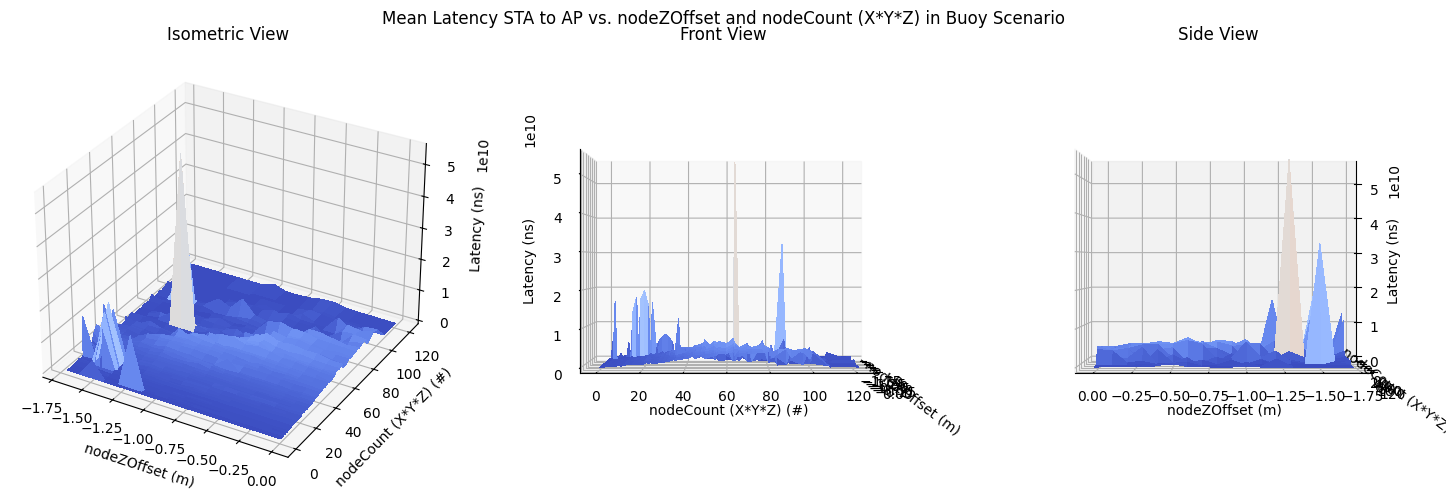

In [8]:
fig = plt.figure(figsize=(15, 5))
fig.suptitle('Mean Latency STA to AP vs. nodeZOffset and nodeCount (X*Y*Z) in Buoy Scenario')

# Create a 2D grid for surface plot
x_unique = np.sort(packet_logging_stats_summary['nodeZOffset'].unique())
y_unique = np.sort(packet_logging_stats_summary['nodeXCount'] * packet_logging_stats_summary['nodeYCount'] * packet_logging_stats_summary['nodeZCount'].unique())

X, Y = np.meshgrid(x_unique, y_unique)
Z = np.zeros(X.shape)

# Map data to grid
for i in range(len(x_unique)):
    for j in range(len(y_unique)):
        node_z_offset = x_unique[i]
        node_count = y_unique[j]
        mask = (packet_logging_stats_summary['nodeZOffset'] == node_z_offset) & \
               (packet_logging_stats_summary['nodeXCount'] * packet_logging_stats_summary['nodeYCount'] * packet_logging_stats_summary['nodeZCount'] == node_count)
        if mask.any():
            Z[j, i] = packet_logging_stats_summary.loc[mask, 'MeanLatencySTAToAP'].mean()

# Isometric view (default 3D view)
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax1.set_xlabel('nodeZOffset (m)')
ax1.set_ylabel('nodeCount (X*Y*Z) (#)')
ax1.set_zlabel('Latency (ns)')
ax1.set_title('Isometric View')

# Front view (looking at X-Z plane)
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax2.set_xlabel('nodeZOffset (m)')
ax2.set_ylabel('nodeCount (X*Y*Z) (#)')
ax2.set_zlabel('Latency (ns)')
ax2.view_init(elev=0, azim=0)
ax2.set_title('Front View')

# Side view (looking at Y-Z plane)
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax3.set_xlabel('nodeZOffset (m)')
ax3.set_ylabel('nodeCount (X*Y*Z) (#)')
ax3.set_zlabel('Latency (ns)')
ax3.view_init(elev=0, azim=90)
ax3.set_title('Side View')

plt.tight_layout()
plt.show()

In [9]:
# Convert time from ns to h
for col in filter(lambda x: x.endswith('Time'), power_state_stats.columns):
    power_state_stats[col] = power_state_stats[col] / 1e9 / 3600

# Multiply the time by the power consumption of each state
# Constants from https://www.nsnam.org/docs/release/3.23/doxygen/classns3_1_1_wifi_radio_energy_model.html
voltage = 3
power_state_stats['RXPower'] = power_state_stats['RXTime'] * voltage * 0.313
power_state_stats['TXPower'] = power_state_stats['TXTime'] * voltage * 0.38
power_state_stats['IDLEPower'] = power_state_stats['IDLETime'] * voltage * 0.273
power_state_stats['SLEEPPower'] = power_state_stats['SLEEPTime'] * voltage * 0.033
power_state_stats['CCA_BUSYPower'] = power_state_stats['CCA_BUSYTime'] * voltage * 0.273
power_state_stats['SWITCHINGPower'] = power_state_stats['SWITCHINGTime'] * voltage * 0.273
power_state_stats['TotalPower'] = power_state_stats['RXPower'] + power_state_stats['TXPower'] + power_state_stats['IDLEPower'] + power_state_stats['SLEEPPower'] + power_state_stats['CCA_BUSYPower'] + power_state_stats['SWITCHINGPower']

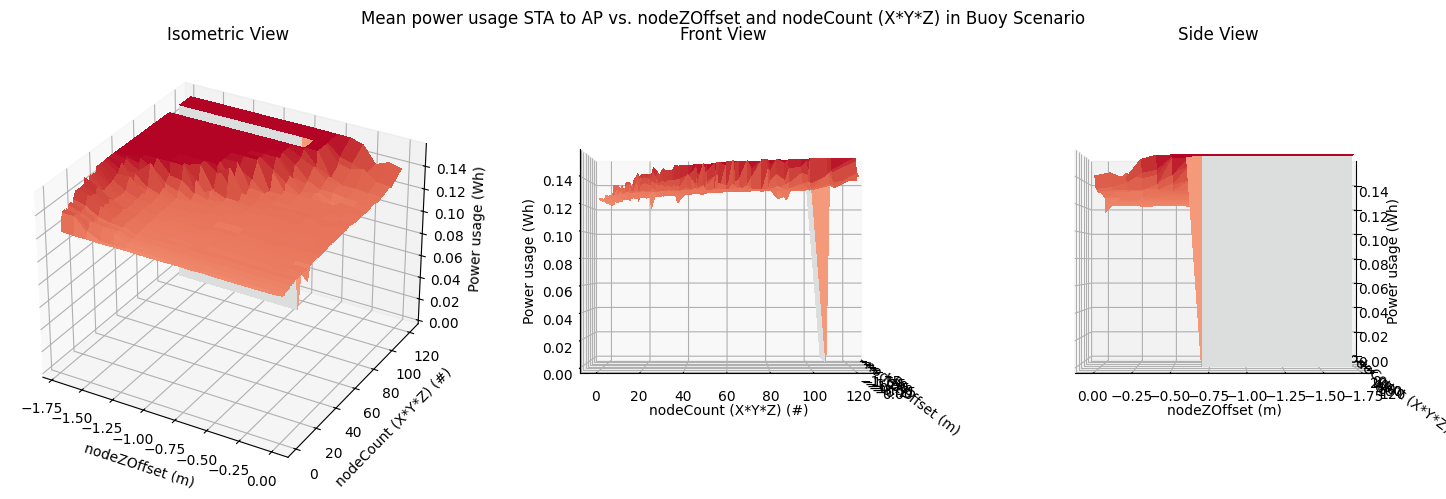

In [10]:
fig = plt.figure(figsize=(15, 5))
fig.suptitle('Mean power usage STA to AP vs. nodeZOffset and nodeCount (X*Y*Z) in Buoy Scenario')

# Create a 2D grid for surface plot
x_unique = np.sort(power_state_stats['nodeZOffset'].unique())
y_unique = np.sort(power_state_stats['nodeXCount'] * power_state_stats['nodeYCount'] * power_state_stats['nodeZCount'].unique())

X, Y = np.meshgrid(x_unique, y_unique)
Z = np.zeros(X.shape)

# Map data to grid
for i in range(len(x_unique)):
    for j in range(len(y_unique)):
        node_z_offset = x_unique[i]
        node_count = y_unique[j]
        mask = (power_state_stats['nodeZOffset'] == node_z_offset) & \
               (power_state_stats['nodeXCount'] * power_state_stats['nodeYCount'] * power_state_stats['nodeZCount'] == node_count)
        if mask.any():
            Z[j, i] = power_state_stats.loc[mask, 'TotalPower'].mean()

# Isometric view (default 3D view)
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax1.set_xlabel('nodeZOffset (m)')
ax1.set_ylabel('nodeCount (X*Y*Z) (#)')
ax1.set_zlabel('Power usage (Wh)')
ax1.set_title('Isometric View')

# Front view (looking at X-Z plane)
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax2.set_xlabel('nodeZOffset (m)')
ax2.set_ylabel('nodeCount (X*Y*Z) (#)')
ax2.set_zlabel('Power usage (Wh)')
ax2.view_init(elev=0, azim=0)
ax2.set_title('Front View')

# Side view (looking at Y-Z plane)
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', linewidth=0, 
                         antialiased=False, rcount=10000, ccount=10000)
ax3.set_xlabel('nodeZOffset (m)')
ax3.set_ylabel('nodeCount (X*Y*Z) (#)')
ax3.set_zlabel('Power usage (Wh)')
ax3.view_init(elev=0, azim=90)
ax3.set_title('Side View')

plt.tight_layout()
plt.show()